# 01 — Análise Exploratória (EDA)

**Objetivo:** entender o dataset Telco Customer Churn antes de modelar e embasar os
insights de negócio do README.

Perguntas guia:
1. Qual a taxa de churn e o quanto o alvo é desbalanceado?
2. Quais segmentos (contrato, internet, pagamento) concentram o churn?
3. Como o tempo de casa (`tenure`) se relaciona com o cancelamento?
4. O que determina `MonthlyCharges`? (justifica a Regressão Linear)

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Permite importar `src` quando o notebook roda a partir de notebooks/
RAIZ = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

from src.config import DATA_PATH, FIGURAS_DIR  # noqa: E402
from src.data import carregar_e_limpar  # noqa: E402

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
FIGURAS_DIR.mkdir(parents=True, exist_ok=True)

df = carregar_e_limpar()
print(df.shape)
df.head()

(7043, 23)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,n_servicos_internet,pagamento_automatico,tem_familia
0,0,0,1,0,1,0,0,DSL,0,1,...,0,Month-to-month,1,Electronic check,29.85,29.85,0,1,0,1
1,1,0,0,0,34,1,0,DSL,1,0,...,0,One year,0,Mailed check,56.95,1889.50,0,2,0,0
2,1,0,0,0,2,1,0,DSL,1,1,...,0,Month-to-month,1,Mailed check,53.85,108.15,1,2,0,0
3,1,0,0,0,45,0,0,DSL,1,0,...,0,One year,0,Bank transfer (automatic),42.30,1840.75,0,3,1,0
4,0,0,0,0,2,1,0,Fiber optic,0,0,...,0,Month-to-month,1,Electronic check,70.70,151.65,1,0,0,0


## 1. Visão geral e qualidade dos dados

In [2]:
# O CSV original traz TotalCharges como texto: quantas linhas vazias?
bruto = pd.read_csv(DATA_PATH)
vazios = bruto["TotalCharges"].str.strip().eq("").sum()
print(f"TotalCharges vazios no CSV bruto: {vazios}")
print("Todos têm tenure = 0?", (bruto.loc[bruto['TotalCharges'].str.strip() == '', 'tenure'] == 0).all())
print(f"Nulos após a limpeza: {df.isna().sum().sum()}")
df[["tenure", "MonthlyCharges", "TotalCharges"]].describe().round(2)

TotalCharges vazios no CSV bruto: 11
Todos têm tenure = 0? True
Nulos após a limpeza: 0


,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7043.00
mean,32.37,64.76,2279.73
std,24.56,30.09,2266.79
min,0.00,18.25,0.00
25%,9.00,35.50,398.55
50%,29.00,70.35,1394.55
75%,55.00,89.85,3786.60
max,72.00,118.75,8684.80


## 2. Variável-alvo: desbalanceamento

In [3]:
taxa = df["Churn"].mean()
print(f"Taxa de churn: {taxa:.1%}  ({df['Churn'].sum()} de {len(df)} clientes)")
print(f"Proporção negativos/positivos: {(1 - taxa) / taxa:.2f}  -> usada em scale_pos_weight")

Taxa de churn: 26.5%  (1869 de 7043 clientes)
Proporção negativos/positivos: 2.77  -> usada em scale_pos_weight


## 3. Churn por segmento

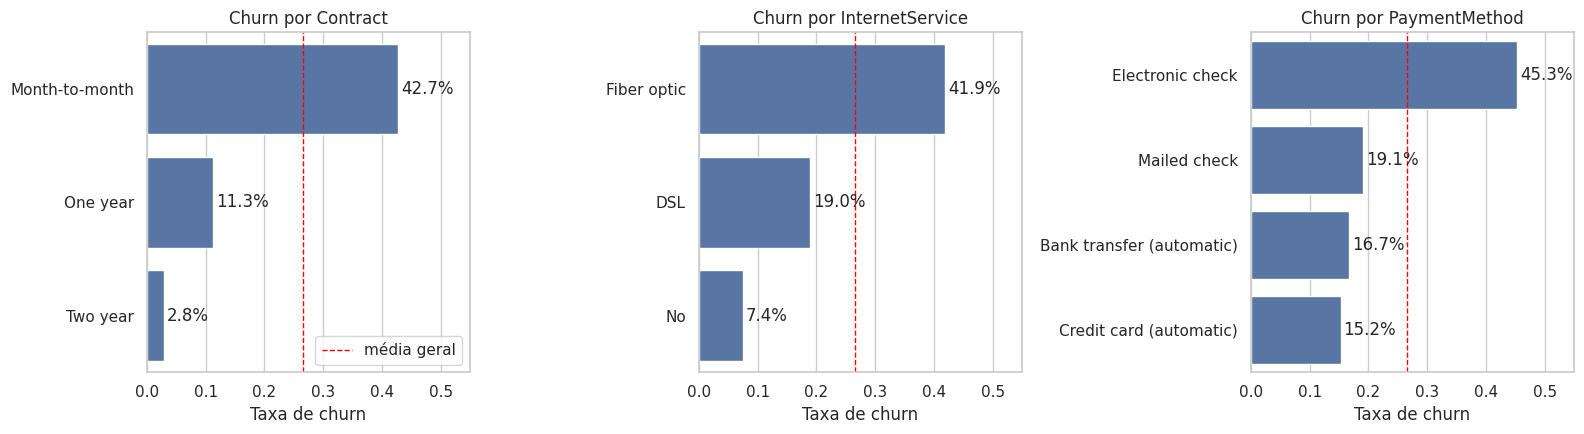

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=False)
for ax, col in zip(axes, ["Contract", "InternetService", "PaymentMethod"]):
    taxas = df.groupby(col)["Churn"].mean().sort_values(ascending=False)
    sns.barplot(x=taxas.values, y=taxas.index, ax=ax, color="#4C72B0")
    ax.set_title(f"Churn por {col}")
    ax.set_xlabel("Taxa de churn")
    ax.set_ylabel("")
    ax.set_xlim(0, 0.55)
    ax.axvline(df["Churn"].mean(), color="red", ls="--", lw=1, label="média geral")
    for i, v in enumerate(taxas.values):
        ax.text(v + 0.005, i, f"{v:.1%}", va="center")
axes[0].legend()
fig.tight_layout()
fig.savefig(FIGURAS_DIR / "eda_churn_segmentos.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Tempo de casa (`tenure`) e mensalidade

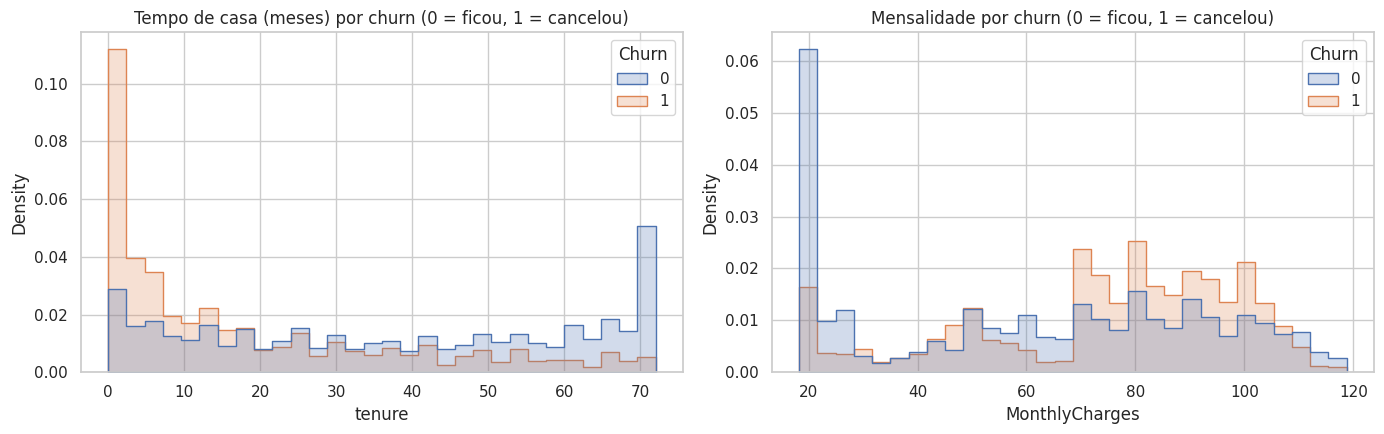

Churn por faixa de tenure (meses):
         taxa  clientes
tenure                 
0-12    0.474      2186
13-24   0.287      1024
25-48   0.204      1594
49-72   0.095      2239

Mediana por grupo:
       tenure  MonthlyCharges
Churn                        
0        38.0          64.425
1        10.0          79.650


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, col, titulo in zip(
    axes, ["tenure", "MonthlyCharges"], ["Tempo de casa (meses)", "Mensalidade"]
):
    sns.histplot(data=df, x=col, hue="Churn", bins=30, stat="density",
                 common_norm=False, element="step", ax=ax)
    ax.set_title(f"{titulo} por churn (0 = ficou, 1 = cancelou)")
fig.tight_layout()
fig.savefig(FIGURAS_DIR / "eda_tenure_mensalidade.png", dpi=150, bbox_inches="tight")
plt.show()

faixas = pd.cut(df["tenure"], [-1, 12, 24, 48, 72],
                labels=["0-12", "13-24", "25-48", "49-72"])
print("Churn por faixa de tenure (meses):")
print(df.groupby(faixas, observed=True)["Churn"].agg(taxa="mean", clientes="size").round(3))
print()
print("Mediana por grupo:")
print(df.groupby("Churn")[["tenure", "MonthlyCharges"]].median())

## 5. Serviços adicionais e churn (apenas clientes com internet)

                      taxa  clientes
n_servicos_internet                 
0                    0.522       693
1                    0.458       966
2                    0.358      1033
3                    0.274      1118
4                    0.223       852
5                    0.124       571
6                    0.053       284


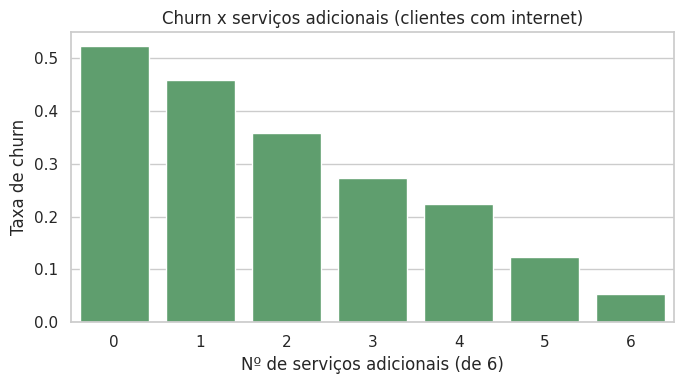

In [6]:
# Clientes sem internet têm 0 serviços "por definição" e churn baixo (~7%);
# incluí-los distorceria a leitura. Filtramos quem tem internet.
com_internet = df[df["InternetService"] != "No"]
por_servicos = com_internet.groupby("n_servicos_internet")["Churn"].agg(
    taxa="mean", clientes="size"
)
print(por_servicos.round(3))

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=por_servicos.index, y=por_servicos["taxa"], color="#55A868", ax=ax)
ax.set(xlabel="Nº de serviços adicionais (de 6)", ylabel="Taxa de churn",
       title="Churn x serviços adicionais (clientes com internet)")
fig.tight_layout()
fig.savefig(FIGURAS_DIR / "eda_churn_servicos.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. O que determina a mensalidade? (justifica a regressão)

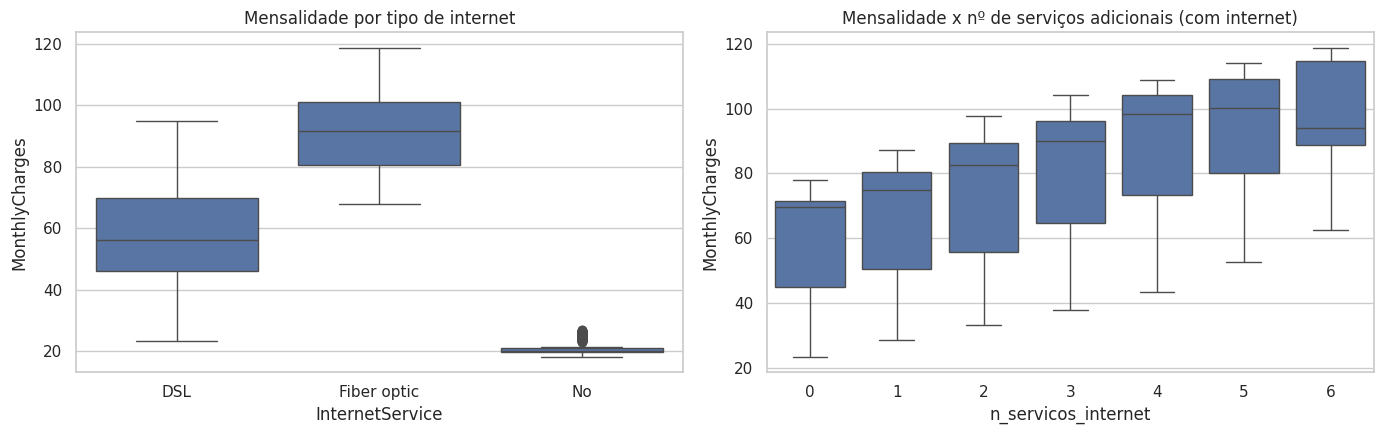

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.boxplot(data=df, x="InternetService", y="MonthlyCharges", ax=axes[0])
axes[0].set_title("Mensalidade por tipo de internet")
sns.boxplot(data=com_internet, x="n_servicos_internet", y="MonthlyCharges", ax=axes[1])
axes[1].set_title("Mensalidade x nº de serviços adicionais (com internet)")
fig.tight_layout()
fig.savefig(FIGURAS_DIR / "eda_mensalidade.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Correlações numéricas

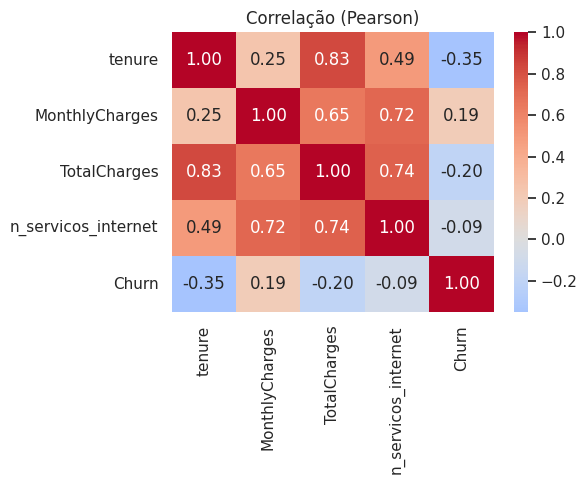

In [8]:
numericas = ["tenure", "MonthlyCharges", "TotalCharges", "n_servicos_internet", "Churn"]
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(df[numericas].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax)
ax.set_title("Correlação (Pearson)")
fig.tight_layout()
plt.show()

## 8. Conclusões da EDA

1. **Desbalanceamento moderado:** 26,5% de churn (razão ~2,77:1). Justifica
   `scale_pos_weight` e reportar Recall/F1/AUC, não apenas acurácia.
2. **Contrato é o maior divisor:** churn de 42,7% no mensal, 11,3% no anual e
   2,8% no bienal.
3. **Os primeiros 12 meses concentram o risco:** 47,4% de churn na faixa 0-12
   meses, contra 9,5% após 49 meses. Quem cancela tem mediana de 10 meses de casa
   (vs. 38 de quem fica).
4. **Fibra ótica e cheque eletrônico** destacam-se: 41,9% e 45,3% de churn
   (média geral: 26,5%). Pagamento automático: 16,0% contra 34,7%.
5. **Serviços adicionais se associam a menos churn** entre clientes com
   internet: de 52,2% (nenhum) a 5,3% (os 6). Isto é **associação, não causa**:
   clientes mais engajados tendem a contratar mais serviços.
6. **Gênero não discrimina** (26,9% vs. 26,2%); idosos cancelam mais
   (41,7% vs. 23,6%).
7. **Mensalidade é quase aditiva:** o tipo de internet e os serviços contratados
   explicam o preço (fibra ~US$ 92 de mediana, DSL ~US$ 56, sem internet ~US$ 20),
   o que antecipa o R² ≈ 0,999 da regressão.
8. **Cuidado com vazamento:** `TotalCharges` é fortemente correlacionada com
   `tenure` (0,83): por isso fica fora da regressão de `MonthlyCharges`.